<a href="https://colab.research.google.com/github/EdithYounes/ASD_Gene_Analysis/blob/main/ASD_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11-Mar-2026 12:06:47 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
11-Mar-2026 12:06:47 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
11-Mar-2026 12:06:47 INFO GEOparse - Parsing ./GSE18123_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE18123_family.soft.gz: 
11-Mar-2026 12:06:47 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
11-Mar-2026 12:06:47 DEBUG GEOparse - SERIES: GSE18123
DEBUG:GEOparse:SERIES: GSE18123
11-Mar-2026 12:06:47 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local/lib/python3.12/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
11-Mar-2026 12:06:56 DEBUG GEOparse - PLATFORM: GPL6244
DEBUG:GEOparse:PLATFORM: GPL6244
11-Mar-2026 12:07:01 DEBUG GEOparse 

Label distribution:
0    213
1     72
Name: count, dtype: int64
Samples: 285
Genes: 5000


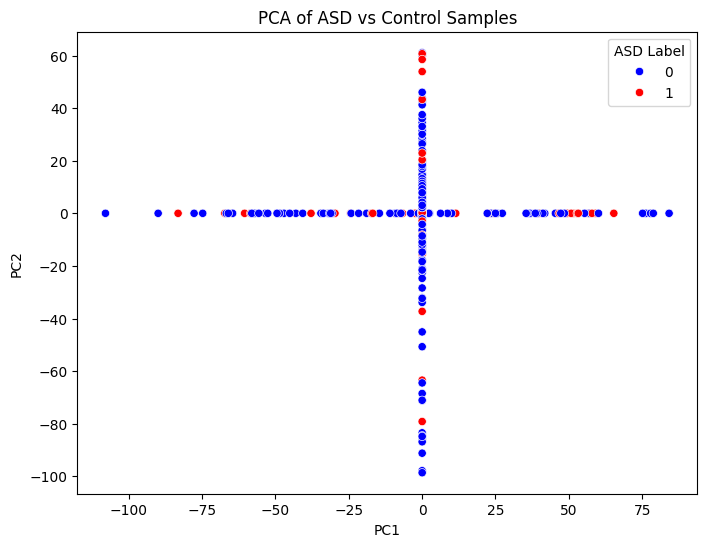

Train Accuracy: 1.0
Test Accuracy: 0.7543859649122807

Classification Report:
              precision    recall  f1-score   support

           0       0.74      1.00      0.85        40
           1       1.00      0.18      0.30        17

    accuracy                           0.75        57
   macro avg       0.87      0.59      0.58        57
weighted avg       0.82      0.75      0.69        57



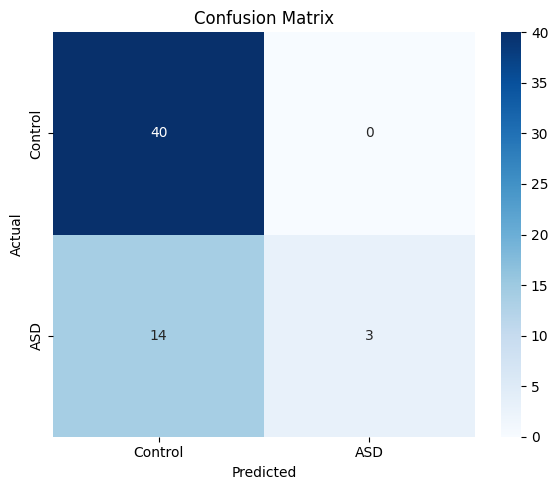

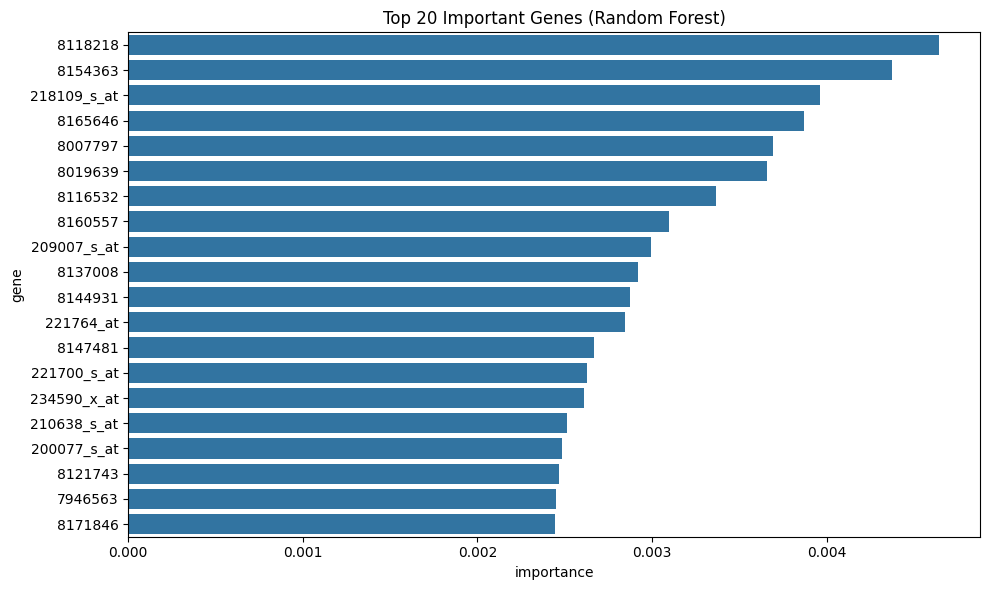

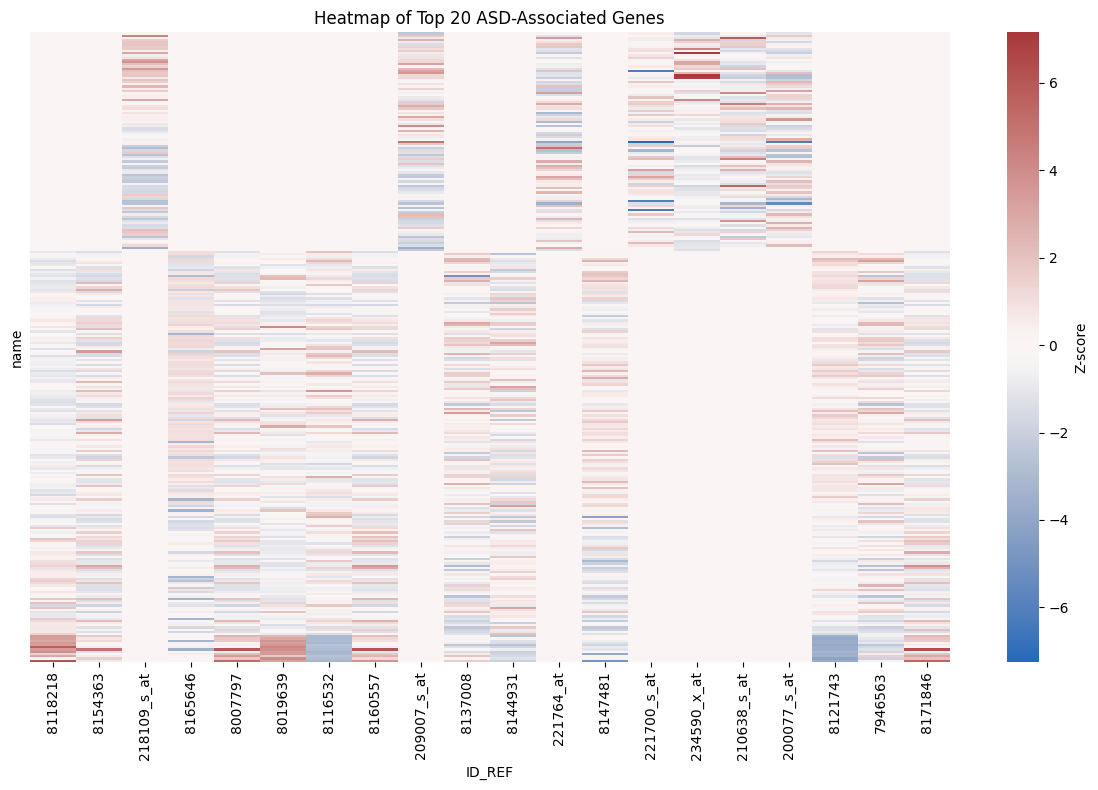

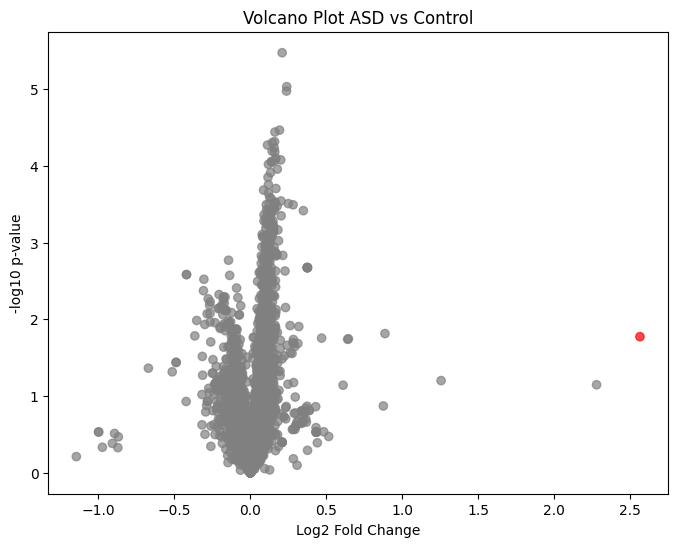


Feature importance with gene symbols:
             gene  importance  \
2830      8118218    0.004646   
2101      8154363    0.004374   
2904  218109_s_at    0.003964   
5         8165646    0.003867   
938       8007797    0.003695   
328       8019639    0.003656   
1390      8116532    0.003368   
816       8160557    0.003094   
2475  209007_s_at    0.002994   
1381      8137008    0.002920   

                                            gene_symbol  
2830                                                NaN  
2101                                                NaN  
2904  major facilitator superfamily domain containing 1  
5                                                   NaN  
938                                                 NaN  
328                                                 NaN  
1390                                                NaN  
816                                                 NaN  
2475  uncharacterized LOC101928189 /// arginine/seri...  
1381             

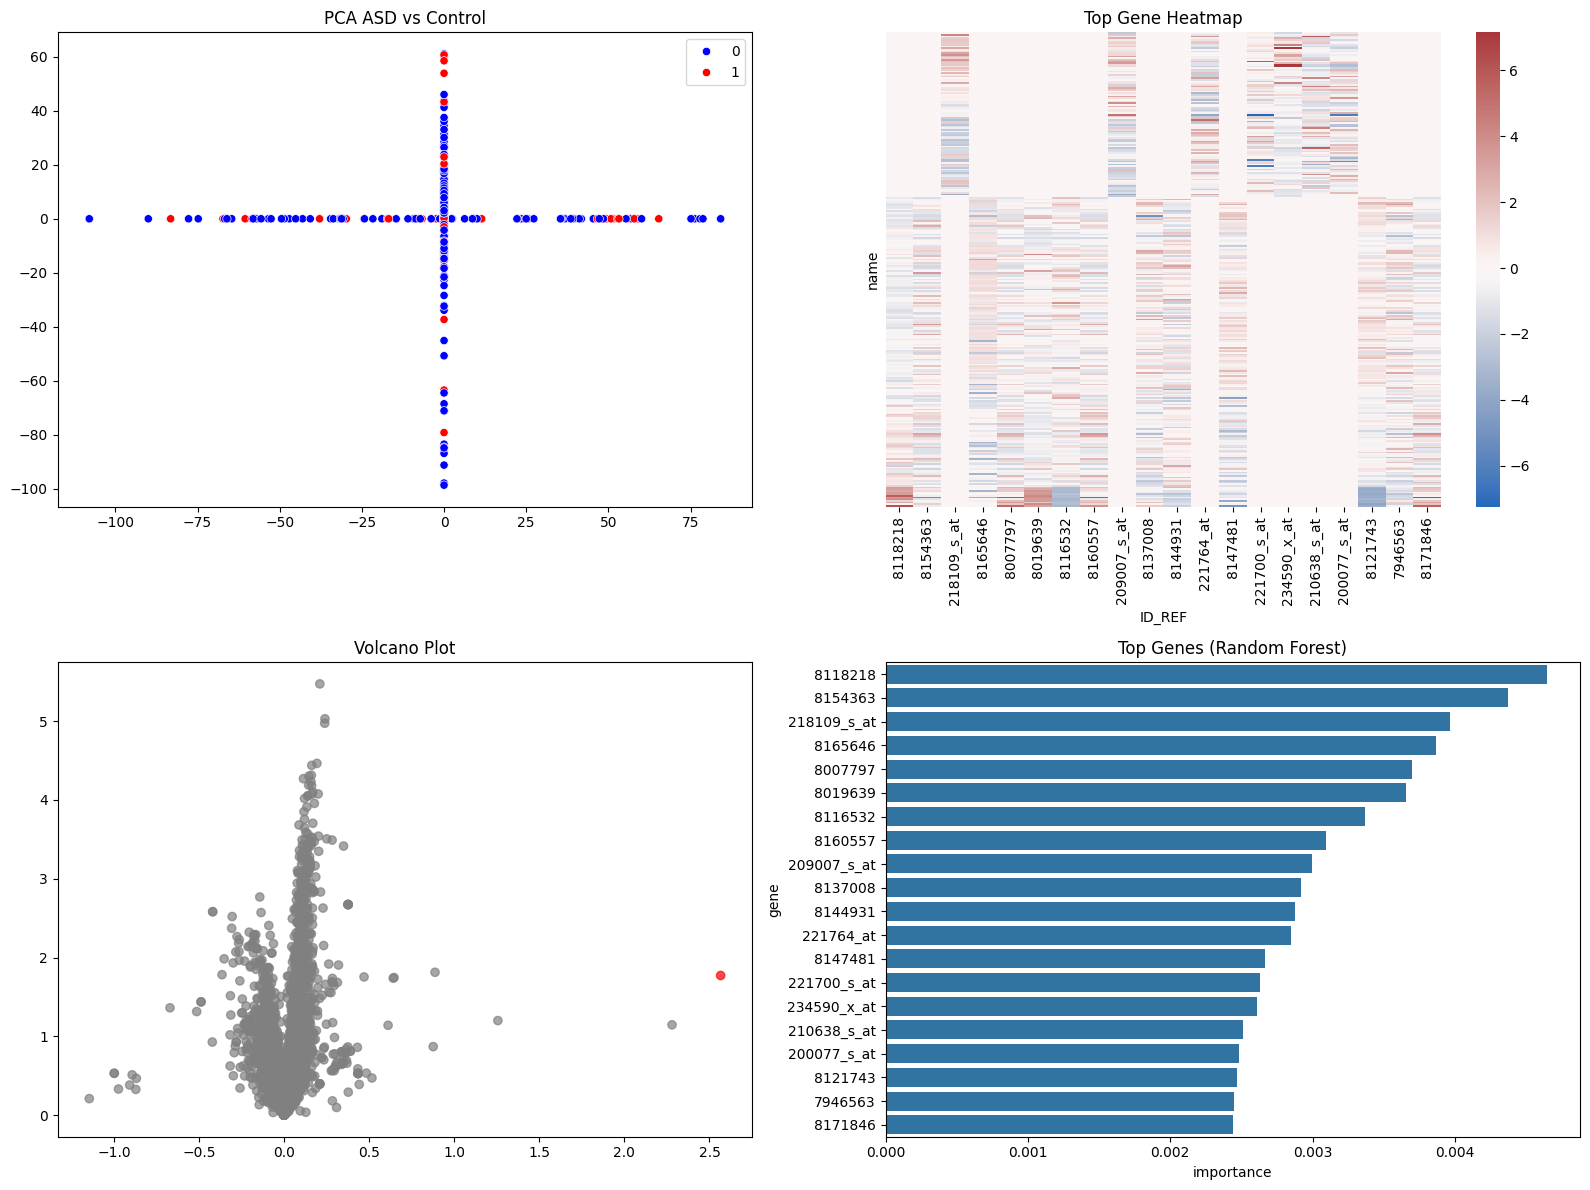


All figures generated successfully.


In [5]:
# ==========================================
# 1️ Install Required Package
# ==========================================

!pip install GEOparse --quiet


# ==========================================
# 2️ Imports
# ==========================================

import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from scipy.stats import ttest_ind


# ==========================================
# 3️ Download GEO Dataset
# ==========================================

gse = GEOparse.get_GEO("GSE18123", destdir="./")

# Expression matrix
expr = gse.pivot_samples("VALUE")


# ==========================================
# 4️ Extract Metadata and Labels
# ==========================================

metadata = {gsm: gse.gsms[gsm].metadata for gsm in gse.gsms}
metadata = pd.DataFrame.from_dict(metadata, orient='index')

metadata["characteristics_clean"] = metadata["characteristics_ch1"].apply(
    lambda x: str(x).lower()
)

# 1 = Autism, 0 = Control
y = metadata["characteristics_clean"].apply(
    lambda x: 1 if "autism" in x else 0
).values

print("Label distribution:")
print(pd.Series(y).value_counts())


# ==========================================
# 5️ Handle Missing Values
# ==========================================

expr_clean = expr.apply(lambda row: row.fillna(row.mean()), axis=1)


# ==========================================
# 6️ Select Most Variable Genes
# ==========================================

gene_variance = expr_clean.var(axis=1)

top_genes = gene_variance.sort_values(ascending=False).head(5000).index
expr_filtered = expr_clean.loc[top_genes]


# ==========================================
# 7️ Prepare Machine Learning Matrix
# ==========================================

X = expr_filtered.T
X.columns = X.columns.astype(str)

print("Samples:", X.shape[0])
print("Genes:", X.shape[1])


# ==========================================
# 8️ Standardize Features
# ==========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ==========================================
# 9️ PCA Visualization
# ==========================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette=["blue","red"]
)

plt.title("PCA of ASD vs Control Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend(title="ASD Label")

plt.savefig("pca_autism_samples.png")
plt.show()


# ==========================================
# 10 Train Random Forest Classifier
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))


# ==========================================
# 11 Model Evaluation
# ==========================================

y_pred = rf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Control","ASD"],
    yticklabels=["Control","ASD"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig("confusion_matrix.png")
plt.show()


# ==========================================
# 1️2️ Feature Importance
# ==========================================

importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "gene": expr_filtered.index,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="gene",
    data=feature_importance.head(20)
)

plt.title("Top 20 Important Genes (Random Forest)")
plt.tight_layout()

plt.savefig("feature_importance_genes.png")
plt.show()


# ==========================================
# 1️3️ Heatmap of Top Genes
# ==========================================

top20_genes = feature_importance.head(20)["gene"].astype(str).values

heatmap_data = X[top20_genes]

heatmap_data = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    cmap="vlag",
    yticklabels=False,
    cbar_kws={'label': 'Z-score'}
)

plt.title("Heatmap of Top 20 ASD-Associated Genes")
plt.tight_layout()

plt.savefig("top20_genes_heatmap.png")
plt.show()


# ==========================================
# 1️4️ Volcano Plot
# ==========================================

group_asd = X.values[y==1]
group_control = X.values[y==0]

logFC = np.log2(group_asd.mean(axis=0)+1e-6) - np.log2(group_control.mean(axis=0)+1e-6)

pvals = np.array([
    ttest_ind(group_asd[:,i], group_control[:,i])[1]
    for i in range(X.shape[1])
])

neg_log_p = -np.log10(pvals + 1e-10)

plt.figure(figsize=(8,6))

plt.scatter(
    logFC,
    neg_log_p,
    c=['red' if (abs(fc)>1 and p<0.05) else 'grey'
       for fc,p in zip(logFC,pvals)],
    alpha=0.7
)

plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10 p-value")
plt.title("Volcano Plot ASD vs Control")

plt.savefig("volcano_plot_autism.png")
plt.show()


# ==========================================
# 1️5️ Gene Annotation
# ==========================================

gpl = gse.gpls[list(gse.gpls.keys())[0]]

annotation_table = gpl.table

gene_symbol_column = None

for col in annotation_table.columns:
    if "gene" in col.lower() or "symbol" in col.lower():
        gene_symbol_column = col
        break

probe_to_gene = annotation_table.set_index("ID")[gene_symbol_column]

feature_importance["gene_symbol"] = feature_importance["gene"].map(probe_to_gene)

print("\nFeature importance with gene symbols:")
print(feature_importance.head(10))


# ==========================================
# 1️6️ Candidate Gene Detection
# ==========================================

top_genes_ml = feature_importance.head(10)["gene"].values
top_genes_pval = np.array(expr_filtered.index)[np.argsort(pvals)[:10]]

candidate_genes = set(top_genes_ml) & set(top_genes_pval)

candidate_table = feature_importance[
    feature_importance["gene"].isin(candidate_genes)
][["gene","gene_symbol","importance"]]

print("\nCandidate genes:")
print(candidate_table)


# ==========================================
# 1️7️ Summary Figure (All Panels)
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16,12))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette=["blue","red"],
    ax=axes[0,0]
)

axes[0,0].set_title("PCA ASD vs Control")

sns.heatmap(
    heatmap_data,
    cmap="vlag",
    yticklabels=False,
    ax=axes[0,1]
)

axes[0,1].set_title("Top Gene Heatmap")

axes[1,0].scatter(
    logFC,
    neg_log_p,
    c=['red' if (abs(fc)>1 and p<0.05) else 'grey'
       for fc,p in zip(logFC,pvals)],
    alpha=0.7
)

axes[1,0].set_title("Volcano Plot")

sns.barplot(
    x="importance",
    y="gene",
    data=feature_importance.head(20),
    ax=axes[1,1]
)

axes[1,1].set_title("Top Genes (Random Forest)")

plt.tight_layout()

plt.savefig("summary_figure_all_panels.png", dpi=300)

plt.show()


print("\nAll figures generated successfully.")